In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from matplotlib import gridspec
from matplotlib.ticker import MultipleLocator
from matplotlib.ticker import NullLocator
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import scienceplots
plt.style.use("science")

import arviz as az

NOTEBOOK_CWD = Path.cwd().resolve()

for candidate in [NOTEBOOK_CWD, *NOTEBOOK_CWD.parents]:
    SRC_DIR = candidate / "section_3" / "src"
    if (SRC_DIR / "simulator.py").exists():
        PROJECT_ROOT = candidate
        break
else:
    raise RuntimeError("Could not find project root")

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import simulator as sim
import inference as inf

FIGURE_DIR = PROJECT_ROOT / "section_3" / "figures" / "validation_2"
RESULT_DIR = PROJECT_ROOT / "section_3" / "results" / "validation_2"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

$\mathcal{M}_1$: heterogeneous in baseline killing decision-making, history effect independent

$\mathcal{M}_2$: homogeneous in baseline killing decision-making, history effect dependent

In [2]:
params_common_m1 = {
    "mean_lambda": 3,
    "sigma_lambda": 1,
    "p0": 0.5,
    "sigma_eta": 0.5,
    "beta_x": 0.0,
    "beta_y": 0.0,
}

params_common_m2 = {
    "mean_lambda": 3,
    "sigma_lambda": 1,
    "p0": 0.5,
    "sigma_eta": 0,
    "beta_x": 0.5,
    "beta_y": 0.5,
}

sample_size = np.array([10, 100, 500])
max_n = int(sample_size.max())
synthetic_data_m1 = {}
synthetic_data_m2 = {}

params_m1 = sim.ContactKillParams(
    n_cells=max_n,
    **params_common_m1,
)

params_m2 = sim.ContactKillParams(
    n_cells=max_n,
    **params_common_m2,
)

df_m1_full = sim.simulate_contact_kill(
    params_m1,
    seed=1,
    return_latent=True,
)

df_m2_full = sim.simulate_contact_kill(
    params_m2,
    seed=2,
    return_latent=True,
)

for n in sample_size:
    n = int(n)

    synthetic_data_m1[n] = df_m1_full.iloc[:n].copy()
    synthetic_data_m2[n] = df_m2_full.iloc[:n].copy()

    print(
        f"n={n}:",
        synthetic_data_m1[n].shape,
        synthetic_data_m2[n].shape,
    )


n=10: (10, 8) (10, 8)
n=100: (100, 8) (100, 8)
n=500: (500, 8) (500, 8)


### Bayesian inference

**$\mathcal{M}_1$** inference

In [3]:
spec = inf.ModelSpec(
    name="M1",
    heterogeneous=True,
    history_dependent=False,
)

idata_m1 = {}

for _, n in enumerate(synthetic_data_m1):
    syn_data = inf.prepare_data(synthetic_data_m1[n])
    
    model = inf.build_model(
        syn_data,
        spec,
        duration=params_m1.duration,
        sigma_lambda_prior=2.0,
        theta_prior_sd=2.0,
        sigma_theta_prior=1.0,
    )
    idata = inf.sample_smc(
        model,
        draws=2000,
        chains=4,
        cores=4,
        random_seed=None,
        prior_draws=2000,
    )
    idata_m1[n] = idata

TypeError: build_model() got an unexpected keyword argument 'theta_prior_sd'. Did you mean 'beta_prior_sd'?

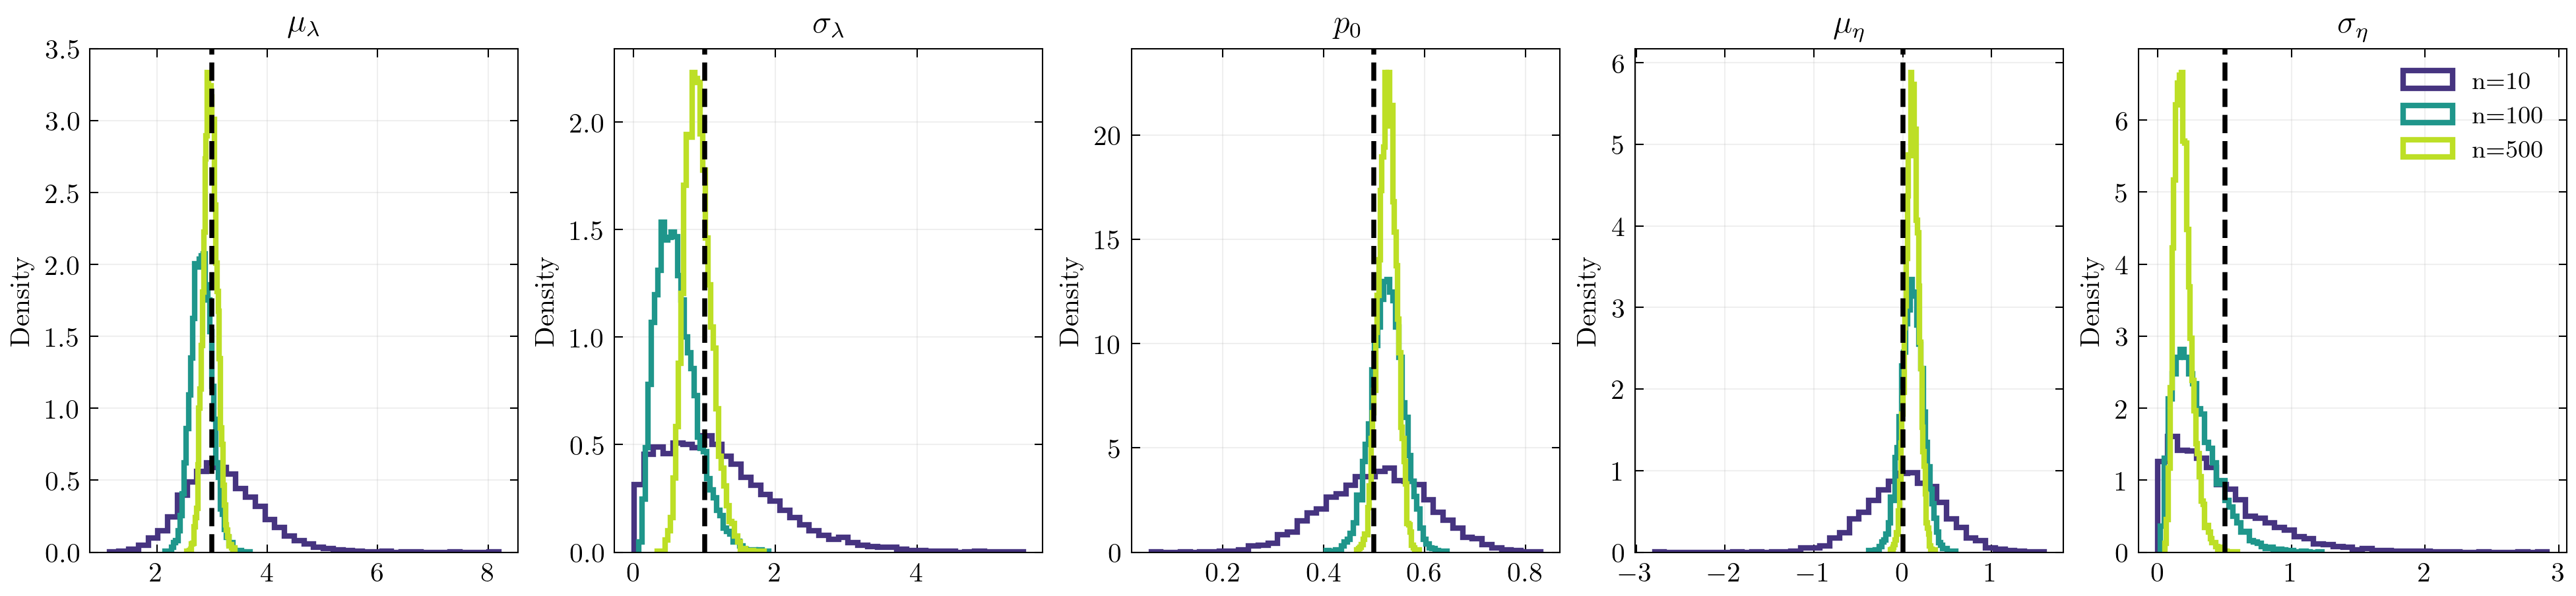

In [ ]:
M1_PARAMS = [
    "mu_lambda",
    "sigma_lambda",
    "p0_mean",
    "mu_theta",
    "sigma_theta",
]

M1_PARAM_DISPLAY = {
    "mu_lambda": r"$\mu_\lambda$",
    "sigma_lambda": r"$\sigma_\lambda$",
    "p0_mean": r"$p_0$",
    "mu_theta": r"$\mu_\eta$",
    "sigma_theta": r"$\sigma_\eta$",
}

M1_TRUTH = {
    "mu_lambda": params_m1.mean_lambda,
    "sigma_lambda": params_m1.sigma_lambda,
    "p0_mean": params_m1.p0,
    "mu_theta": sim.logit(params_m1.p0),
    "sigma_theta": params_m1.sigma_eta,
}

def posterior_values(idata, param, *, sample_size=8000, seed=123):
    if param not in idata.posterior:
        return np.array([], dtype=float)

    values = (
        idata.posterior[param]
        .stack(sample=("chain", "draw"))
        .values
        .ravel()
    )
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if values.size > sample_size:
        rng = np.random.default_rng(seed)
        values = rng.choice(values, sample_size, replace=False)

    return values

def plot_m1_posterior_marginals(
    idata_by_n,
    *,
    parameters=M1_PARAMS,
    truth=M1_TRUTH,
    parameter_display=M1_PARAM_DISPLAY,
    sample_size=8000,
    bins=40,
    cmap="viridis",
    figsize=(13, 3.0),
    dpi=300,
    save_path=None,
):
    n_values = sorted(idata_by_n)
    colors = plt.colormaps[cmap](np.linspace(0.15, 0.9, len(n_values)))

    fig, axes = plt.subplots(
        1,
        len(parameters),
        figsize=figsize,
        dpi=dpi,
        constrained_layout=True,
    )

    if len(parameters) == 1:
        axes = [axes]

    for ax, param in zip(axes, parameters):
        for color, n in zip(colors, n_values):
            vals = posterior_values(
                idata_by_n[n],
                param,
                sample_size=sample_size,
                seed=123 + int(n),
            )

            if vals.size == 0:
                continue

            ax.hist(
                vals,
                bins=bins,
                density=True,
                histtype="step",
                linewidth=2,
                color=color,
                label=f"n={n}",
            )

        if param in truth:
            ax.axvline(
                truth[param],
                color="black",
                linestyle="--",
                linewidth=1.8,
            )

        ax.set_title(parameter_display.get(param, param))
        ax.set_ylabel("Density")
        ax.grid(True, alpha=0.2)
        ax.xaxis.set_minor_locator(NullLocator())
        ax.yaxis.set_minor_locator(NullLocator())
        ax.tick_params(axis="both", labelsize=10)

    axes[-1].legend(frameon=False, fontsize=9)

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path)

    return fig, axes

fig, axes = plot_m1_posterior_marginals(
    idata_m1,
    save_path=FIGURE_DIR / "m1_posterior_marginals_by_sample_size.svg",
)